DistilBERT model loading and fine tuning processs


In [1]:
import pandas as pd
from datasets import Dataset
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
import torch

DistilBERT fine tuning with LIAR testing and and evaluating LIAR training.


In [2]:
import pandas as pd

train_df = pd.read_csv("LIAR dataset/train modified.tsv", sep="\t")
test_df = pd.read_csv("LIAR dataset/test modified.tsv", sep="\t")

def convert_label(label):
    return 1 if label.lower() in ['true', 'mostly-true'] else 0

train_df['label'] = train_df['label'].apply(convert_label)
test_df['label'] = test_df['label'].apply(convert_label)

train_df = train_df[['statement', 'label']]
test_df = test_df[['statement', 'label']]

train_df.head()

,statement,label
0,Says the Annies List political group supports ...,0
1,When did the decline of coal start? It started...,0
2,"Hillary Clinton agrees with John McCain ""by vo...",1
3,Health care reform legislation is likely to ma...,0
4,The economic turnaround started at the end of ...,0


In [3]:

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize(example):
    return tokenizer(example['statement'], truncation=True, padding="max_length", max_length=256)

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

Map:   0%|          | 0/10240 [00:00<?, ? examples/s]

Map:   0%|          | 0/1267 [00:00<?, ? examples/s]

In [ ]:

model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    save_total_limit=1,
    logging_dir="./logs",
    load_best_model_at_end=True,
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\Users\alber\anaconda3\envs\ai-testing\lib\site-packages\transformers\training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

trainer.train()


Epoch,Training Loss,Validation Loss
1,0.629500,0.609008
2,0.574800,0.618191
3,0.449100,0.819559


TrainOutput(global_step=1920, training_loss=0.5036376237869262, metrics={'train_runtime': 792.2579, 'train_samples_per_second': 38.775, 'train_steps_per_second': 2.423, 'total_flos': 2034699243356160.0, 'train_loss': 0.5036376237869262, 'epoch': 3.0})

Accuracy:  0.6756
Precision: 0.5586
Recall:    0.4031
F1 Score:  0.4683

Classification Report:
               precision    recall  f1-score   support

       False       0.72      0.83      0.77       818
        True       0.56      0.40      0.47       449

    accuracy                           0.68      1267
   macro avg       0.64      0.61      0.62      1267
weighted avg       0.66      0.68      0.66      1267



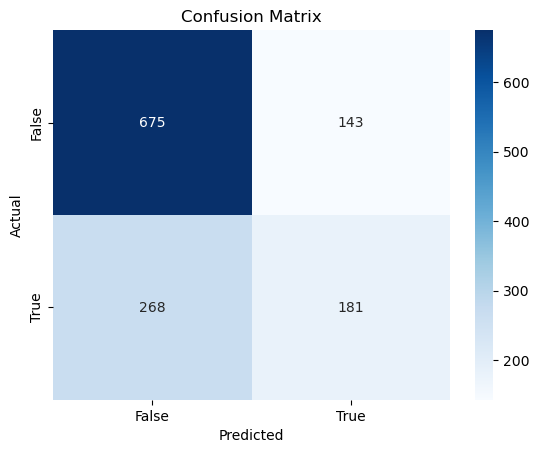

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=["False", "True"]))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["False", "True"], yticklabels=["False", "True"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
model.save_pretrained("distilbert_liar_model")
tokenizer.save_pretrained("distilbert_liar_model")

('distilbert_liar_model\\tokenizer_config.json',
 'distilbert_liar_model\\special_tokens_map.json',
 'distilbert_liar_model\\vocab.txt',
 'distilbert_liar_model\\added_tokens.json',
 'distilbert_liar_model\\tokenizer.json')

Data preprocessing to match columns for the datasets


In [4]:
import pandas as pd

cleaned_true_quotes_df = pd.read_csv(
    "ReNew dataset/true combined dataset (with titles).csv", 
    encoding='ISO-8859-1'
)

cleaned_true_quotes_df = cleaned_true_quotes_df.rename(columns={"quotes": "statement"})
cleaned_true_quotes_df['label'] = 1

cleaned_true_quotes_df = cleaned_true_quotes_df[['statement', 'label']].dropna(subset=['statement'])

cleaned_true_quotes_df = cleaned_true_quotes_df.head(200)

print("cleaned_true_quotes_df shape:", cleaned_true_quotes_df.shape)
cleaned_true_quotes_df.tail(5)


cleaned_true_quotes_df shape: (200, 2)


,statement,label
195,Prices of things like televisions and toys are...,1
196,The largest private pension bailout in America...,1
197,The administration is shamefully further restr...,1
198,Milwaukee is on pace for a third straight homi...,1
199,"In the first three quarters of 2022, the railr...",1


In [6]:
import pandas as pd

with open("./ReNew dataset/fake combined dataset (200).csv", encoding='windows-1252', errors='replace') as file:
    cleaned_false_quotes_df = pd.read_csv(file, sep=';', quotechar='"', on_bad_lines='skip')

cleaned_false_quotes_df.columns = cleaned_false_quotes_df.columns.str.strip()

cleaned_false_quotes_df = cleaned_false_quotes_df.drop(columns=['statement'], errors='ignore')
cleaned_false_quotes_df = cleaned_false_quotes_df.rename(columns={'quotes': 'statement'})

cleaned_false_quotes_df = cleaned_false_quotes_df[~cleaned_false_quotes_df['target'].isin(['TRUE', 'mostly-true'])]

cleaned_false_quotes_df['label'] = 0

cleaned_false_quotes_df = cleaned_false_quotes_df[['statement', 'label']].head(200)

print("cleaned_false_quotes_df shape:", cleaned_false_quotes_df.shape)
cleaned_false_quotes_df.head(5)


cleaned_false_quotes_df shape: (200, 2)


,statement,label
0,"If the Dow drops 1,000 points in two days the ...",0
1,Elon Musk said: Here's the hard truth: this co...,0
3,DOGE discovers Louisiana man with 34 different...,0
4,The ‘Texas measles outbreak’ is pure propagand...,0
5,If Donald Trump stops federal funding to Maine...,0


Combining LIAR and ReNew datasets


In [ ]:
curated_df = pd.concat([train_df, cleaned_true_quotes_df, cleaned_false_quotes_df], ignore_index=True)

curated_df = curated_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("curated_df shape:", curated_df.shape)
curated_df.tail(5)


curated_df shape: (10640, 2)


,statement,label
10635,"When I took office, the deficit was nearly 10 ...",0
10636,On the mosque near ground zero.,1
10637,Louie Gohmert of Texas blamed the mass shootin...,0
10638,The Governor did not consult members of his ow...,0
10639,A telecom bill could keep the State Corporatio...,0


In [ ]:
from sklearn.model_selection import train_test_split

train_statements, temp_statements, train_labels, temp_labels = train_test_split(
    curated_df["statement"],
    curated_df["label"],
    test_size=0.2,
    stratify=curated_df["label"],
    random_state=42
)

val_statements, test_statements, val_labels, test_labels = train_test_split(
    temp_statements,
    temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

print("Train size:", len(train_statements))
print("Validation size:", len(val_statements))
print("Test size:", len(test_statements))

print("\nUnique labels in training set:", train_labels.unique())
print("Unique labels in validation set:", val_labels.unique())
print("Unique labels in test set:", test_labels.unique())


Train size: 8512
Validation size: 1064
Test size: 1064

Unique labels in training set: [1 0]
Unique labels in validation set: [0 1]
Unique labels in test set: [0 1]


In [ ]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize_statements(statements):
    cleaned = statements.fillna("").astype(str).tolist()
    return tokenizer(
        cleaned,
        padding="max_length",
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )

train_encodings = tokenize_statements(train_statements)
val_encodings = tokenize_statements(val_statements)
test_encodings = tokenize_statements(test_statements)

print("Sample input_ids (train):", train_encodings["input_ids"][0][:10])
print("Sample attention_mask (train):", train_encodings["attention_mask"][0][:10])


Sample input_ids (train): tensor([  101,  3305,  1010,  2023,  2003, 12163,  5427,  1012,  2049,  2025])
Sample attention_mask (train): tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


In [ ]:
import torch
from torch.utils.data import Dataset

class FakeNewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        return {
            key: val[idx] for key, val in self.encodings.items()
        } | {"labels": torch.tensor(self.labels[idx])}

    def __len__(self):
        return len(self.labels)

train_dataset = FakeNewsDataset(train_encodings, train_labels.tolist())
val_dataset = FakeNewsDataset(val_encodings, val_labels.tolist())
test_dataset = FakeNewsDataset(test_encodings, test_labels.tolist())


In [ ]:
from transformers import DistilBertForSequenceClassification, Trainer, TrainingArguments

model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir="./logs",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss"
)

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\Users\alber\anaconda3\envs\ai-testing\lib\site-packages\transformers\training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.622500,0.649771,0.646617,0.547619,0.119792,0.196581
2,0.513700,0.641954,0.652256,0.530702,0.315104,0.395425
3,0.397400,0.983886,0.625000,0.480211,0.473958,0.477064


TrainOutput(global_step=3192, training_loss=0.5260435677411264, metrics={'train_runtime': 1449.3557, 'train_samples_per_second': 17.619, 'train_steps_per_second': 2.202, 'total_flos': 3382687492079616.0, 'train_loss': 0.5260435677411264, 'epoch': 3.0})

Accuracy: 0.6654135338345865
Precision: 0.5603448275862069
Recall: 0.3385416666666667
F1 Score: 0.42207792207792205

Classification Report:
              precision    recall  f1-score   support

       False       0.69      0.85      0.76       680
        True       0.56      0.34      0.42       384

    accuracy                           0.67      1064
   macro avg       0.63      0.59      0.59      1064
weighted avg       0.65      0.67      0.64      1064



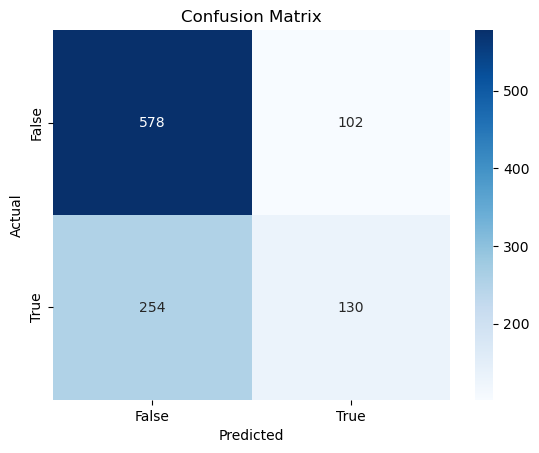

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

print("Accuracy:", accuracy_score(labels, preds))
print("Precision:", precision_recall_fscore_support(labels, preds, average='binary')[0])
print("Recall:", precision_recall_fscore_support(labels, preds, average='binary')[1])
print("F1 Score:", precision_recall_fscore_support(labels, preds, average='binary')[2])

print("\nClassification Report:")
print(classification_report(labels, preds, target_names=["False", "True"]))

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["False", "True"], yticklabels=["False", "True"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
save_path = "distilbert_liar_200_curated_model"

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print(f"Model and tokenizer saved to '{save_path}'")


Model and tokenizer saved to 'distilbert_liar_200_curated_model'


Using the cleaned datasets to evaluate performance in the LIAR only model.


Data Preprocessing: combining both csv files completely as one


In [7]:
import pandas as pd

true_file_path = "./ReNew dataset/renew true cleaned parsed (balanced version).csv"
false_file_path = "./ReNew dataset/renew false cleaned parsed (balanced version).csv"

true_renew_df = pd.read_csv(true_file_path, usecols=["quotes", "label"], encoding="latin1", sep=";")
false_renew_df = pd.read_csv(false_file_path, usecols=["quotes", "label"], encoding="latin1", sep=";")

true_renew_df["label"] = true_renew_df["label"].map({True: 1, False: 0})
false_renew_df["label"] = false_renew_df["label"].map({True: 1, False: 0})

print(true_renew_df.head())
print(false_renew_df.head())


   label                                             quotes
0      1  Well, you have to have the funding in order to...
1      1  90% of the (school) districts in Wisconsin alr...
2      1  The law does not require judges to automatical...
3      1  We're one of the very few nations that allowed...
4      1  And let me say this, as a Californian, we have...
   label                                             quotes
0      0  Kevin O'Leary said all fat not cutting enough ...
1      0  I am not making this up: Republicans have intr...
2      0  Not about balancing the budget. We all know th...
3      0  That is why the Biden administration was pushi...
4      0  You either have XX or XY chromosomes. Barring ...


In [ ]:
import pandas as pd

combined_renew_df = pd.concat([true_renew_df, false_renew_df], ignore_index=True)

combined_renew_df = combined_renew_df.sample(frac=1, random_state=42).reset_index(drop=True)

combined_renew_df = combined_renew_df.rename(columns={"quotes": "statement"})

print(combined_renew_df.tail(15))


      label                                          statement
2619      0  President Biden wants Iowans and Americans to ...
2620      1  There are, literally, two pharmaceutical lobby...
2621      0  In this beautiful state of Wisconsin, after Ro...
2622      1  Beyonce paid $100K for Maryland Metro to run l...
2623      0  We've also reduced the debt and reduced the de...
2624      0  Illegals SHOULD NOT BE VOTING in American elec...
2625      1  Even after accounting for rising prices, the t...
2626      1  The White House staff risks violating federal ...
2627      1  Last year, oil and gas was about 35% of the st...
2628      0  Charlie Crist thinks Joe Biden is the best pre...
2629      0  I've been delivering real results in fiscally ...
2630      1  Claire McCaskill voted for 100 percent of Pres...
2631      1  For Republicans, the race for governor is crys...
2632      1  Central Park actually used to be a town called...
2633      1  People show up in the emergency room with 

In [ ]:
combined_renew_df = combined_renew_df.dropna(subset=["statement"]).reset_index(drop=True)


In [ ]:
import torch
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained('distilbert_liar_model')
tokenizer = DistilBertTokenizer.from_pretrained('distilbert_liar_model')


In [ ]:
def preprocess_text(text):
    return tokenizer(text, padding=True, truncation=True, return_tensors="pt", max_length=512)

inputs = tokenizer(combined_renew_df['statement'].tolist(), padding=True, truncation=True, return_tensors="pt", max_length=512)


In [ ]:
nan_statements = combined_renew_df[combined_renew_df['statement'].isna()]
nan_labels = combined_renew_df[combined_renew_df['label'].isna()]

print("Rows with NaN in 'statement' column:")
print(nan_statements)

print("\nRows with NaN in 'label' column:")
print(nan_labels)

Rows with NaN in 'statement' column:
Empty DataFrame
Columns: [label, statement]
Index: []

Rows with NaN in 'label' column:
Empty DataFrame
Columns: [label, statement]
Index: []


2. DistilBERT (trained with LIAR). Tested in: ReNew Testing \*\*


In [ ]:
model = DistilBertForSequenceClassification.from_pretrained('distilbert_liar_model')
tokenizer = DistilBertTokenizer.from_pretrained('distilbert_liar_model')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


In [ ]:
original_model = DistilBertForSequenceClassification.from_pretrained("distilbert_liar_model")
original_model.to(device)
original_model.eval()


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
class RenewDataset(Dataset):
    def __init__(self, dataframe, tokenizer):
        self.texts = dataframe["statement"].tolist()
        self.labels = dataframe["label"].tolist()
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=512,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }


In [ ]:
from torch.utils.data import DataLoader, TensorDataset

# Create datasets
train_dataset = RenewDataset(train_df, tokenizer)
test_dataset = RenewDataset(test_df, tokenizer)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)


In [ ]:
from tqdm import tqdm
original_preds = []
original_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = original_model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        original_preds.extend(preds.cpu().numpy())
        original_labels.extend(labels.cpu().numpy())

print("Original (pre-fine-tuning) Accuracy:", accuracy_score(original_labels, original_preds))
print(classification_report(original_labels, original_preds, digits=4))


100%|██████████| 66/66 [00:08<00:00,  7.96it/s]

Original (pre-fine-tuning) Accuracy: 0.6470588235294118
              precision    recall  f1-score   support

           0     0.5941    0.9240    0.7232       263
           1     0.8305    0.3712    0.5131       264

    accuracy                         0.6471       527
   macro avg     0.7123    0.6476    0.6182       527
weighted avg     0.7125    0.6471    0.6180       527



In [20]:
combined_renew_df.to_csv("./Cleaned dataset/renew/combined/combined renew dataset.csv", index=False)
train_df.to_csv("./Cleaned dataset/renew/combined/combined renew train.csv", index=False)
test_df.to_csv("./Cleaned dataset/renew/combined/combined renew test.csv", index=False)